Cell 1 import library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay)
from xgboost import XGBClassifier
import joblib


cell 2 load and preprocessing

In [2]:
df = pd.read_csv('../data/gempa_1990-2026.csv')
df = df[df['type'] == 'earthquake'].copy()

df['time'] = pd.to_datetime(df['time'])
df['bulan'] = df['time'].dt.month
df['jam']   = df['time'].dt.hour

fitur = ['latitude', 'longitude', 'depth', 'gap', 'dmin', 'nst', 'bulan', 'jam']

for col in ['gap', 'dmin', 'nst']:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col] = df[col].fillna(df[col].median())

df_clean = df[fitur].dropna().reset_index(drop=True)

print(f"Total data: {df_clean.shape[0]} baris")


Total data: 63413 baris


cell 3 isolation forest (generate label)

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean)

# Eksperimen 3 nilai contamination
hasil_if = {}
for c in [0.01, 0.05, 0.10]:
    iso = IsolationForest(contamination=c, n_estimators=100, random_state=42)
    pred = iso.fit_predict(X_scaled)
    label = (pred == -1).astype(int)  # -1 = anomali = 1, 1 = normal = 0
    hasil_if[c] = label
    print(f"Contamination {c}: {label.sum()} anomali ({label.mean()*100:.1f}%)")


Contamination 0.01: 635 anomali (1.0%)
Contamination 0.05: 3171 anomali (5.0%)
Contamination 0.1: 6342 anomali (10.0%)


cell 4 pilih contamination and buat label final

In [4]:
# Pakai contamination 0.05 (5%) — bisa diubah setelah melihat hasil
contamination_terpilih = 0.05
df_clean['label'] = hasil_if[contamination_terpilih]

print(f"Normal : {(df_clean['label'] == 0).sum()}")
print(f"Anomali: {(df_clean['label'] == 1).sum()}")


Normal : 60242
Anomali: 3171


cell 5 split data

In [5]:
X = df_clean[fitur]
y = df_clean['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")


Train: (50730, 8), Test: (12683, 8)


cell 6 tuning XGBoost

In [6]:
scale = (y_train == 0).sum() / (y_train == 1).sum() * 10

param_grid = {
    'n_estimators'    : [100, 200, 300],
    'max_depth'       : [3, 5, 6, 8],
    'learning_rate'   : [0.01, 0.05, 0.1, 0.2],
    'subsample'       : [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'min_child_weight': [1, 3, 5]
}

base = XGBClassifier(scale_pos_weight=scale, eval_metric='logloss', random_state=42)
search = RandomizedSearchCV(base, param_grid, n_iter=30, scoring='f1',
                            cv=5, random_state=42, n_jobs=-1, verbose=1)
search.fit(X_train, y_train)

print("Best params:", search.best_params_)
print("Best F1 CV :", round(search.best_score_, 4))


Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params: {'subsample': 1.0, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': 0.2, 'colsample_bytree': 0.8}
Best F1 CV : 0.8733


cell 7 training final dengan early stopping

In [7]:
model = XGBClassifier(**search.best_params_, scale_pos_weight=scale,
                      eval_metric='aucpr', early_stopping_rounds=20, random_state=42)
model.fit(X_train, y_train,
          eval_set=[(X_train, y_train), (X_test, y_test)],
          verbose=False)

print(f"Best iteration: {model.best_iteration}")


Best iteration: 299


cell 8 evaluasi lengkap

In [8]:
y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]
y_pred_train = model.predict(X_train)

print("Accuracy (train) :", round(accuracy_score(y_train, y_pred_train), 4))
print("Accuracy (test)  :", round(accuracy_score(y_test, y_pred), 4))
print("Precision        :", round(precision_score(y_test, y_pred, pos_label=1), 4))
print("Recall Anomali   :", round(recall_score(y_test, y_pred, pos_label=1), 4))
print("F1 Anomali       :", round(f1_score(y_test, y_pred, pos_label=1), 4))
print("AUC-ROC          :", round(roc_auc_score(y_test, y_proba), 4))


Accuracy (train) : 1.0
Accuracy (test)  : 0.9877
Precision        : 0.8444
Recall Anomali   : 0.9243
F1 Anomali       : 0.8825
AUC-ROC          : 0.9978


cell 9 confusion matrix

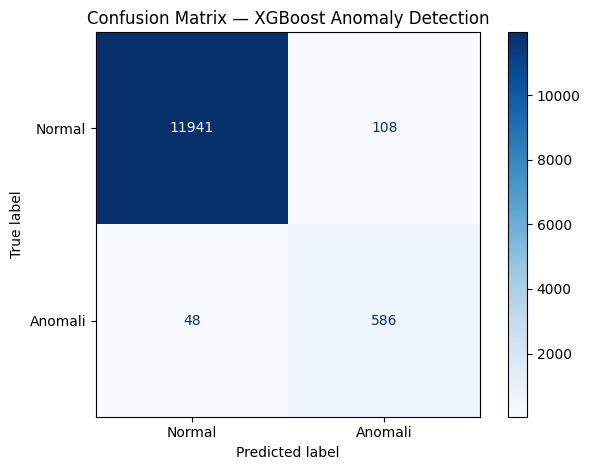

In [9]:
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Anomali']).plot(cmap='Blues')
plt.title('Confusion Matrix — XGBoost Anomaly Detection')
plt.tight_layout()
plt.show()


cell 10 SHAP

c:\Users\fuadf\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


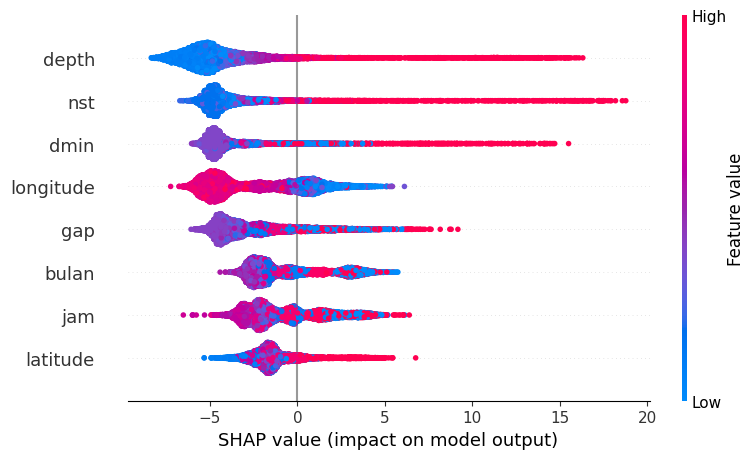

In [10]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, feature_names=fitur)


cell 11 simpan model

In [11]:
joblib.dump(model, '../model_anomali.pkl')
joblib.dump(scaler, '../scaler_anomali.pkl')
print("Model berhasil disimpan")


Model berhasil disimpan
